In [33]:
# Import libraries for data manipulation
import pandas as pd
import numpy as np

# Import visualization libraries
import matplotlib.pyplot as plt
import seaborn as sns

# Import machine learning tools
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

# Import evaluation metrics
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
from sklearn.metrics import roc_curve
from sklearn.metrics import roc_auc_score

# Library to save or load trained model
import pickle

In [34]:
# Load dataset

data = pd.read_csv("microfinance_final_project_dataset.csv")

# Display first 5 rows
data.head()

,applicant_id,age,gender,region,education,employment,employment_years,monthly_income,loan_amount,loan_duration,interest_rate,loan_purpose,credit_score,dependents,previous_loans,repayment_history,collateral,debt_to_income_ratio,loan_status
0,100000,30,Female,Southeast Asia,Secondary,Farmer,4,17781,15506,36,22.61,Medical,456,4,3,Good,No,0.073,0
1,100001,36,Female,Southeast Asia,Postgraduate,Self-employed,18,7571,30852,24,17.88,Agriculture,795,3,4,Poor,Yes,0.340,0
2,100002,46,Male,Latin America,Graduate,Small Business,17,6762,101174,12,23.14,Medical,593,3,2,Average,Yes,1.247,0
3,100003,41,Male,Southeast Asia,Primary,Small Business,11,34389,22645,36,25.71,Agriculture,442,0,1,Good,Yes,0.055,0
4,100004,30,Male,Sub-Saharan Africa,Secondary,Self-employed,28,34942,149135,36,22.83,Housing,548,0,0,Good,Yes,0.356,1


In [35]:
# Display dataset information

data.info()

# Show statistical summary
data.describe()

<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 19 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   applicant_id          5000 non-null   int64  
 1   age                   5000 non-null   int64  
 2   gender                5000 non-null   str    
 3   region                5000 non-null   str    
 4   education             5000 non-null   str    
 5   employment            5000 non-null   str    
 6   employment_years      5000 non-null   int64  
 7   monthly_income        5000 non-null   int64  
 8   loan_amount           5000 non-null   int64  
 9   loan_duration         5000 non-null   int64  
 10  interest_rate         5000 non-null   float64
 11  loan_purpose          5000 non-null   str    
 12  credit_score          5000 non-null   int64  
 13  dependents            5000 non-null   int64  
 14  previous_loans        5000 non-null   int64  
 15  repayment_history     5000 non-n

,applicant_id,age,employment_years,monthly_income,loan_amount,loan_duration,interest_rate,credit_score,dependents,previous_loans,debt_to_income_ratio,loan_status
count,5000.000000,5000.000000,5000.00000,5000.00000,5000.000000,5000.000000,5000.000000,5000.0000,5000.000000,5000.000000,5000.000000,5000.000000
mean,102499.500000,42.378000,14.37460,28061.01380,77829.965400,19.119600,20.131140,576.5144,2.500600,2.490000,0.309594,0.397000
std,1443.520003,12.740721,8.59748,12715.96643,42214.800791,10.242201,4.635029,159.2262,1.706394,1.691648,0.283063,0.489325
min,100000.000000,21.000000,0.00000,6004.00000,5038.000000,6.000000,12.000000,300.0000,0.000000,0.000000,0.009000,0.000000
25%,101249.750000,31.000000,7.00000,17096.25000,41300.000000,12.000000,16.067500,439.0000,1.000000,1.000000,0.122000,0.000000
50%,102499.500000,42.000000,14.00000,28091.50000,77641.000000,18.000000,20.270000,581.0000,3.000000,2.000000,0.235000,0.000000
75%,103749.250000,54.000000,22.00000,38908.00000,114921.000000,24.000000,24.180000,713.0000,4.000000,4.000000,0.386250,1.000000
max,104999.000000,64.000000,29.00000,49992.00000,149990.000000,36.000000,28.000000,849.0000,5.000000,5.000000,2.056000,1.000000


In [36]:
# Display dataset information such as column names and data types

data.info()

# Display statistical summary of numerical features
data.describe()

<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 19 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   applicant_id          5000 non-null   int64  
 1   age                   5000 non-null   int64  
 2   gender                5000 non-null   str    
 3   region                5000 non-null   str    
 4   education             5000 non-null   str    
 5   employment            5000 non-null   str    
 6   employment_years      5000 non-null   int64  
 7   monthly_income        5000 non-null   int64  
 8   loan_amount           5000 non-null   int64  
 9   loan_duration         5000 non-null   int64  
 10  interest_rate         5000 non-null   float64
 11  loan_purpose          5000 non-null   str    
 12  credit_score          5000 non-null   int64  
 13  dependents            5000 non-null   int64  
 14  previous_loans        5000 non-null   int64  
 15  repayment_history     5000 non-n

,applicant_id,age,employment_years,monthly_income,loan_amount,loan_duration,interest_rate,credit_score,dependents,previous_loans,debt_to_income_ratio,loan_status
count,5000.000000,5000.000000,5000.00000,5000.00000,5000.000000,5000.000000,5000.000000,5000.0000,5000.000000,5000.000000,5000.000000,5000.000000
mean,102499.500000,42.378000,14.37460,28061.01380,77829.965400,19.119600,20.131140,576.5144,2.500600,2.490000,0.309594,0.397000
std,1443.520003,12.740721,8.59748,12715.96643,42214.800791,10.242201,4.635029,159.2262,1.706394,1.691648,0.283063,0.489325
min,100000.000000,21.000000,0.00000,6004.00000,5038.000000,6.000000,12.000000,300.0000,0.000000,0.000000,0.009000,0.000000
25%,101249.750000,31.000000,7.00000,17096.25000,41300.000000,12.000000,16.067500,439.0000,1.000000,1.000000,0.122000,0.000000
50%,102499.500000,42.000000,14.00000,28091.50000,77641.000000,18.000000,20.270000,581.0000,3.000000,2.000000,0.235000,0.000000
75%,103749.250000,54.000000,22.00000,38908.00000,114921.000000,24.000000,24.180000,713.0000,4.000000,4.000000,0.386250,1.000000
max,104999.000000,64.000000,29.00000,49992.00000,149990.000000,36.000000,28.000000,849.0000,5.000000,5.000000,2.056000,1.000000


In [37]:
# Check missing values in dataset

data.isnull().sum()

applicant_id            0
age                     0
gender                  0
region                  0
education               0
employment              0
employment_years        0
monthly_income          0
loan_amount             0
loan_duration           0
interest_rate           0
loan_purpose            0
credit_score            0
dependents              0
previous_loans          0
repayment_history       0
collateral              0
debt_to_income_ratio    0
loan_status             0
dtype: int64

In [38]:
# Handle missing values separately for numeric and categorical columns

# Fill numeric columns with mean
num_cols = data.select_dtypes(include=['int64','float64']).columns
data[num_cols] = data[num_cols].fillna(data[num_cols].mean())

# Fill categorical columns with mode
cat_cols = data.select_dtypes(include=['object']).columns

for col in cat_cols:
    data[col] = data[col].fillna(data[col].mode()[0])

C:\Users\DELL\AppData\Local\Temp\ipykernel_14792\2229216700.py:8: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = data.select_dtypes(include=['object']).columns


In [39]:
# Separate features (X) and target variable (y)

X = data.drop("loan_status", axis=1)   # input features
y = data["loan_status"]                # target variable

In [40]:
# Convert categorical columns into numerical using one-hot encoding

X = pd.get_dummies(X, drop_first=True)

In [41]:
# Split dataset into training and testing sets

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [42]:
# Create Random Forest model

model = RandomForestClassifier(random_state=42)

# Train model on training data

model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [43]:
# Calculate feature importance from Random Forest model

importance = model.feature_importances_

# Create dataframe for feature importance
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': importance
})

# Sort features by importance
feature_importance = feature_importance.sort_values(by="Importance", ascending=False)

# Display top 10 most important features
print("Top Features Influencing Loan Default:")
print(feature_importance.head(10))

Top Features Influencing Loan Default:
                   Feature  Importance
7             credit_score    0.142396
10    debt_to_income_ratio    0.110771
3           monthly_income    0.083211
4              loan_amount    0.078602
6            interest_rate    0.075857
0             applicant_id    0.074690
1                      age    0.062215
2         employment_years    0.059703
26  repayment_history_Poor    0.051697
8               dependents    0.034997


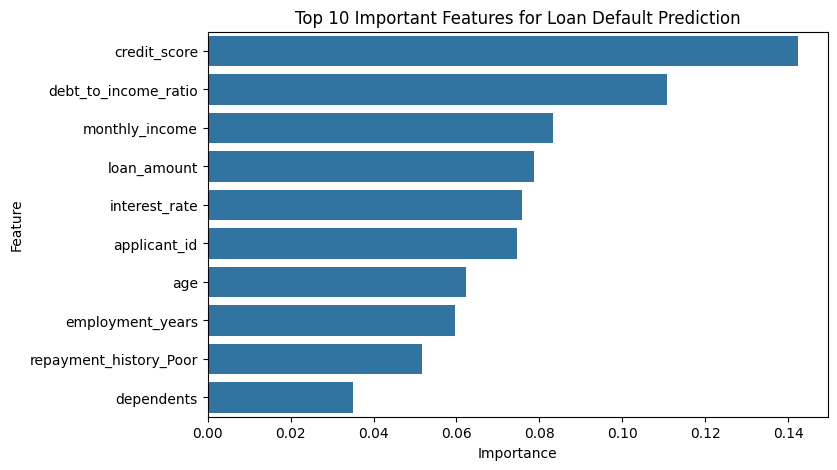

In [44]:
# Plot top 10 important features

plt.figure(figsize=(8,5))

sns.barplot(
    x=feature_importance["Importance"][:10],
    y=feature_importance["Feature"][:10]
)

plt.title("Top 10 Important Features for Loan Default Prediction")

plt.show()

In [45]:
# Save trained model

pickle.dump(model, open("trained_model.pkl", "wb"))

In [46]:
# Predict class labels (0 or 1)

y_pred = model.predict(X_test)

# Predict probability of default

y_prob = model.predict_proba(X_test)[:,1]

In [47]:
# Calculate accuracy

accuracy = accuracy_score(y_test, y_pred)

print("Model Accuracy:", accuracy)

Model Accuracy: 0.74


In [48]:
#Cross Validation 
from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(model, X, y, cv=5)

print("Cross Validation Scores:", cv_scores)
print("Average CV Score:", cv_scores.mean())

Cross Validation Scores: [0.748 0.735 0.722 0.716 0.736]
Average CV Score: 0.7314


In [49]:
# Generate confusion matrix

cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[596  12]
 [248 144]]


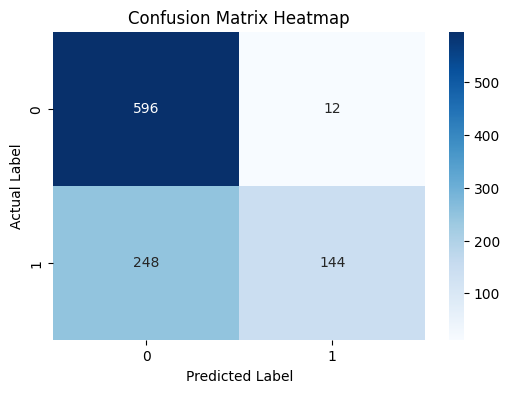

In [50]:
# Visualize confusion matrix using heatmap

plt.figure(figsize=(6,4))

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")

plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.title("Confusion Matrix Heatmap")

plt.show()

In [51]:
# Print classification report

print("Classification Report:")
print(classification_report(y_test, y_pred))

Classification Report:
              precision    recall  f1-score   support

           0       0.71      0.98      0.82       608
           1       0.92      0.37      0.53       392

    accuracy                           0.74      1000
   macro avg       0.81      0.67      0.67      1000
weighted avg       0.79      0.74      0.71      1000



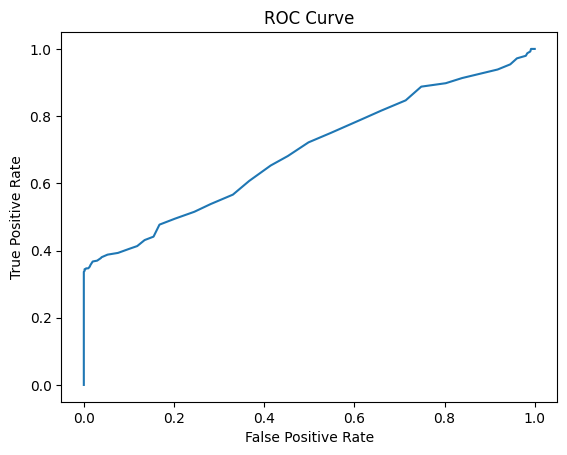

In [52]:
# Compute ROC curve

fpr, tpr, thresholds = roc_curve(y_test, y_prob)

# Plot ROC curve

plt.figure()

plt.plot(fpr, tpr)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("ROC Curve")

plt.show()

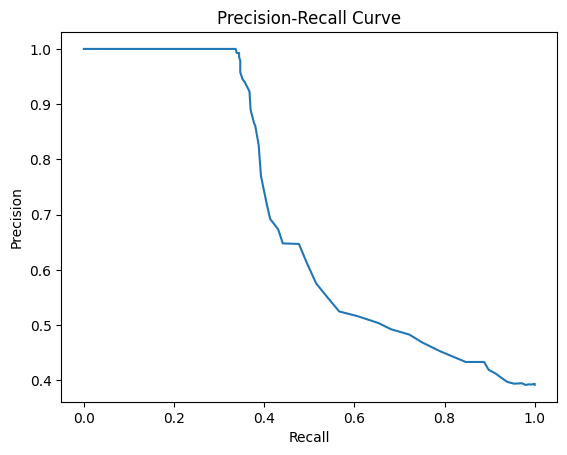

In [53]:
#Precision-Recall Curve
from sklearn.metrics import precision_recall_curve

precision, recall, thresholds = precision_recall_curve(y_test, y_prob)

plt.figure()
plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.show()

In [54]:
# Calculate AUC score

auc = roc_auc_score(y_test, y_prob)

print("AUC Score:", auc)

AUC Score: 0.6935712607411385


In [55]:
# Calculate Gini coefficient

gini = 2 * auc - 1

print("Gini Coefficient:", gini)

Gini Coefficient: 0.387142521482277


In [56]:
# Predict risk for a single applicant using only credit score

# Create a row with average values for all features
new_person = X.mean().to_frame().T

# Change only the credit score
new_person["credit_score"] = 500   # you can change this value

# Predict risk
prediction = model.predict(new_person)
probability = model.predict_proba(new_person)[:,1]

print("Credit Score:", new_person["credit_score"].values[0])
print("Default Probability:", probability[0])

if prediction[0] == 1:
    print("Risk Level: HIGH RISK")
else:
    print("Risk Level: LOW RISK")

Credit Score: 500
Default Probability: 0.27
Risk Level: LOW RISK


In [57]:
# Calculate KS Statistic

from scipy.stats import ks_2samp

# Separate probabilities for each class
prob_default = y_prob[y_test == 1]
prob_non_default = y_prob[y_test == 0]

# Compute KS statistic
ks_statistic = ks_2samp(prob_default, prob_non_default)

print("KS Statistic:", ks_statistic.statistic)

KS Statistic: 0.34761009667024706


In [58]:
# Create evaluation dataset

evaluation = X_test.copy()

evaluation["Actual"] = y_test
evaluation["Prediction"] = y_pred

In [59]:
# Set custom threshold

threshold = 0.45

# Generate predictions using new threshold

y_pred_new = (y_prob > threshold).astype(int)

In [60]:
# Calculate accuracy with new threshold

accuracy_new = accuracy_score(y_test, y_pred_new)

print("Accuracy with new threshold:", accuracy_new)

Accuracy with new threshold: 0.716


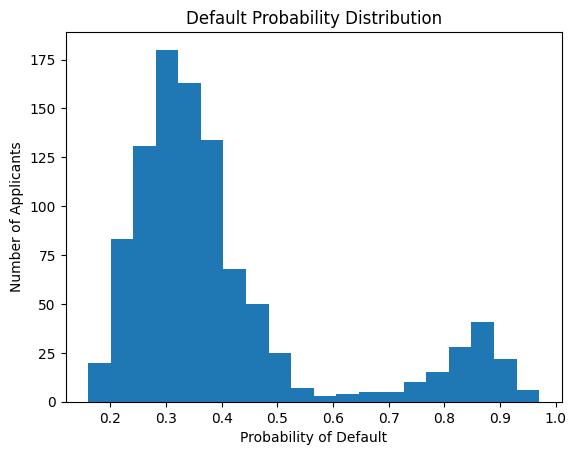

In [61]:
# Plot histogram of predicted probabilities

plt.figure()

plt.hist(y_prob, bins=20)

plt.xlabel("Probability of Default")
plt.ylabel("Number of Applicants")

plt.title("Default Probability Distribution")

plt.show()

In [62]:
# Print final evaluation summary

print("Final Model Evaluation Results")

print("Accuracy:", accuracy)
print("AUC Score:", auc)
print("Gini Coefficient:", gini)

Final Model Evaluation Results
Accuracy: 0.74
AUC Score: 0.6935712607411385
Gini Coefficient: 0.387142521482277
